<a href="https://colab.research.google.com/github/Ridzzz0Alam/data_cleaning_and_preprocessing/blob/main/Assignment05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 05 - Feature Engineering & Regression Modeling
**Dataset:** `student_dataset_dirty.csv`

This notebook covers:
- Part A: Data Cleaning
- Part B: Feature Engineering
- Part C: Linear Regression (predict `Total_Score`)
- Part D: Logistic Regression (predict `Result`)

> This is a **basic starter template**. Fill in the TODOs, add your own analysis, plots, and explanations.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
%matplotlib inline

## Part A — Data Cleaning & Preparation

### 1. Load Data and Initial Inspection
We load the dataset and check its shape, data types, and summary statistics to understand the structure and identify issues.

In [3]:
df = pd.read_csv('student_dataset_dirty.csv')
print("Shape:", df.shape)
df.head()

Shape: (10000, 15)


,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
0,1978,Bristi Khan,16,MALE,Mymensingh,Eight,77.0,2.6,83,62,68,213.0,PRIMARY,no,FAIL
1,3881,hasan akter,12,F,Dhaka,10th,88.5,3.8,45,56,92,193.0,Secondary,NO,fail
2,53,Sohan Talukder,14,Male,Khulna,7th,65.1,3.6,37,82,89,208.0,NaN,NO,fail
3,2552,Mitu Hossain,11,FEMALE,Rajshahi,Ten,82.8,4.2,83,96,59,238.0,illiterate,N,PASS
4,2247,Ayesha Ahmed,14,other,KHULNA,9th,94.2,1.4,81,36,48,165.0,primary,0,pass


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  object 
 1   Name                   9958 non-null   object 
 2   Age                    9804 non-null   object 
 3   Gender                 9162 non-null   object 
 4   City                   9775 non-null   object 
 5   Class                  10000 non-null  object 
 6   Attendance_Percentage  9745 non-null   float64
 7   Study_Hours_per_day    9803 non-null   float64
 8   Math_Score             9805 non-null   object 
 9   Science_Score          9800 non-null   object 
 10  English_Score          9804 non-null   object 
 11  Total_Score            9684 non-null   object 
 12  Parent_Education       8900 non-null   object 
 13  Internet_Access        8354 non-null   object 
 14  Result                 8906 non-null   object 
dtypes: 

In [4]:
df.describe(include='all')

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
count,10000,9958,9804,9162,9775,10000,9745.000000,9803.000000,9805,9800,9804,9684,8900,8354,8906
unique,9850,385,96,11,28,16,NaN,NaN,195,193,194,380,16,10,8
top,8534,Kabir Ahmed,17,male,rangpur,9,NaN,NaN,81,59,96,203.0,Higher Secondary,yes,Fail
freq,2,53,1253,865,636,748,NaN,NaN,159,170,158,111,595,875,1187
mean,NaN,NaN,NaN,NaN,NaN,NaN,84.708897,3.200857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,18.511125,2.800264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,-49.400000,-5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,78.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,84.800000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,91.800000,4.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Report Missing Values, Duplicates, and Inconsistencies

In [5]:
# Missing values per column
print("Missing Values")
missing = df.isna().sum()
print(missing[missing > 0])

Missing Values
Name                       42
Age                       196
Gender                    838
City                      225
Attendance_Percentage     255
Study_Hours_per_day       197
Math_Score                195
Science_Score             200
English_Score             196
Total_Score               316
Parent_Education         1100
Internet_Access          1646
Result                   1094
dtype: int64


In [6]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 150
Shape after dropping duplicates: (9850, 15)


In [7]:
# Inconsistent categorical labels
for col in ['Gender', 'City', 'Class', 'Parent_Education', 'Internet_Access', 'Result']:
    print(f"\n{col} unique values: {df[col].dropna().unique().tolist()}")


Gender unique values: ['MALE', 'F', 'Male', 'FEMALE', 'other', 'M', 'female', 'Female', 'male', 'Other', 'O']

City unique values: ['Mymensingh', 'Dhaka ', 'Khulna', 'Rajshahi', 'KHULNA ', 'sylhet', 'Barisal', 'Mymensign', 'Rangpur', 'Dacca', 'CHATTOGRAM', 'mymensingh', 'khulna', 'Sylhet', 'Chattogram', 'DHAKA', 'rangpur', 'chittagong', 'Chittagong', '  Dhaka', 'Barishal', 'Ctg', 'SYLHET', 'rajshahi', 'Rajshahi ', 'Dhaka', 'dhaka', 'barisal']

Class unique values: ['Eight', '10th', '7th', 'Ten', '9th', '10', '8th', 'Seven', '7', '06', '6th', '9', 'Six', 'Nine', '6', '8']

Parent_Education unique values: ['PRIMARY', 'Secondary', 'illiterate', 'primary', 'GRADUATE', 'higher secondary', 'Primary', 'Post Graduate', 'Unknown', 'Graduate', 'Illiterate', 'graduate', 'Higher Secondary', 'unknown', 'postgraduate', 'secondary']

Internet_Access unique values: ['no', 'NO', 'N', '0', 'No', 'Y', '1', 'yes', 'YES', 'Yes']

Result unique values: ['FAIL', 'fail', 'PASS', 'pass', 'Pass', 'P', 'Fail', 

In [8]:
# Invalid / wrong data types — several numeric columns are stored as object (string)
print("Columns stored as object that should be numeric:")
for c in ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Total_Score']:
    non_num = df[c].dropna()[pd.to_numeric(df[c], errors='coerce').isna()]
    print(f"  {c}: non-numeric entries -> {non_num.unique().tolist()}")

Columns stored as object that should be numeric:
  Age: non-numeric entries -> ['fifteen']
  Math_Score: non-numeric entries -> ['absent']
  Science_Score: non-numeric entries -> ['absent']
  English_Score: non-numeric entries -> ['absent']
  Total_Score: non-numeric entries -> ['error']


### 3. Data Cleaning

Steps to CLean Data:
1. Remove duplicate rows.
2. Standardize categorical text (map inconsistent labels to clean values).
3. Fix wrong data types that is convert numeric columns from object to float, coercing invalid entries (e.g. 'absent', 'error', 'fifteen') to NaN.
4. Handle outliers, replace values outside valid ranges with NaN (Age 5-25, Attendance 0-100, Study Hours 0-16, Scores 0-100). We use range-based invalidation because domain knowledge gives us hard boundaries; values outside these ranges are clearly data entry errors, not statistical outliers.
5. Handle missing values using two strategies:
   - Numeric columns to median imputation (robust to skew, unaffected by outliers).
   - Categorical columns to mode imputation (uses the most frequent category).

In [9]:
# Step 1: Removing duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (9850, 15)


In [10]:
# Step 2: Standardizing categorical text

# Gender
gender_map = {
    'Male': 'Male', 'male': 'Male', 'MALE': 'Male', 'M': 'Male',
    'Female': 'Female', 'female': 'Female', 'FEMALE': 'Female', 'F': 'Female',
    'Other': 'Other', 'other': 'Other', 'O': 'Other'
}
df['Gender'] = df['Gender'].map(gender_map)

# City
city_map = {
    'Dhaka': 'Dhaka', 'DHAKA': 'Dhaka', 'dhaka': 'Dhaka', 'Dhaka ': 'Dhaka',
    '  Dhaka': 'Dhaka', 'Dacca': 'Dhaka',
    'Chittagong': 'Chattogram', 'chittagong': 'Chattogram', 'Chattogram': 'Chattogram',
    'CHATTOGRAM': 'Chattogram', 'Ctg': 'Chattogram',
    'Khulna': 'Khulna', 'khulna': 'Khulna', 'KHULNA ': 'Khulna',
    'Rajshahi': 'Rajshahi', 'rajshahi': 'Rajshahi', 'Rajshahi ': 'Rajshahi',
    'Sylhet': 'Sylhet', 'sylhet': 'Sylhet', 'SYLHET': 'Sylhet',
    'Rangpur': 'Rangpur', 'rangpur': 'Rangpur',
    'Barisal': 'Barisal', 'barisal': 'Barisal', 'Barishal': 'Barisal',
    'Mymensingh': 'Mymensingh', 'mymensingh': 'Mymensingh', 'Mymensign': 'Mymensingh'
}
df['City'] = df['City'].map(city_map)

# Class
class_map = {
    '6': '6', '06': '6', '6th': '6', 'Six': '6',
    '7': '7', '7th': '7', 'Seven': '7',
    '8': '8', '8th': '8', 'Eight': '8',
    '9': '9', '9th': '9', 'Nine': '9',
    '10': '10', '10th': '10', 'Ten': '10'
}
df['Class'] = df['Class'].map(class_map)

# Parent_Education
edu_map = {
    'Illiterate': 'Illiterate', 'illiterate': 'Illiterate',
    'Primary': 'Primary', 'primary': 'Primary', 'PRIMARY': 'Primary',
    'Secondary': 'Secondary', 'secondary': 'Secondary',
    'Higher Secondary': 'Higher Secondary', 'higher secondary': 'Higher Secondary',
    'Graduate': 'Graduate', 'graduate': 'Graduate', 'GRADUATE': 'Graduate',
    'Post Graduate': 'Post Graduate', 'postgraduate': 'Post Graduate',
    'N/A': np.nan, 'Unknown': np.nan, 'unknown': np.nan
}
df['Parent_Education'] = df['Parent_Education'].map(edu_map)

# Internet_Access
internet_map = {
    'Yes': 'Yes', 'yes': 'Yes', 'YES': 'Yes', 'Y': 'Yes', '1': 'Yes',
    'No': 'No', 'no': 'No', 'NO': 'No', 'N': 'No', '0': 'No'
}
df['Internet_Access'] = df['Internet_Access'].map(internet_map)

# Result
result_map = {
    'Pass': 'pass', 'pass': 'pass', 'PASS': 'pass', 'P': 'pass',
    'Fail': 'fail', 'fail': 'fail', 'FAIL': 'fail', 'F': 'fail'
}
df['Result'] = df['Result'].map(result_map)

print("After standardization:")
for col in ['Gender', 'City', 'Class', 'Parent_Education', 'Internet_Access', 'Result']:
    print(f"  {col}: {df[col].dropna().unique().tolist()}")

After standardization:
  Gender: ['Male', 'Female', 'Other']
  City: ['Mymensingh', 'Dhaka', 'Khulna', 'Rajshahi', 'Sylhet', 'Barisal', 'Rangpur', 'Chattogram']
  Class: ['8', '10', '7', '9', '6']
  Parent_Education: ['Primary', 'Secondary', 'Illiterate', 'Graduate', 'Higher Secondary', 'Post Graduate']
  Internet_Access: ['No', 'Yes']
  Result: ['fail', 'pass']


In [11]:
# Step 3: Fixing wrong data types by converting to numeric, coercing invalid entries to NaN
for c in ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Total_Score']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print("Data types after conversion:")
print(df[['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Total_Score']].dtypes)

Data types after conversion:
Age              float64
Math_Score       float64
Science_Score    float64
English_Score    float64
Total_Score      float64
dtype: object


In [12]:
# Step 4: Handle outliers by replace values outside valid domain ranges with NaN
# The reason to do this is becoz of hard physical/domain limits; values outside are data entry errors.
df.loc[(df['Age'] < 5) | (df['Age'] > 25), 'Age'] = np.nan
df.loc[(df['Attendance_Percentage'] < 0) | (df['Attendance_Percentage'] > 100), 'Attendance_Percentage'] = np.nan
df.loc[(df['Study_Hours_per_day'] < 0) | (df['Study_Hours_per_day'] > 16), 'Study_Hours_per_day'] = np.nan

for c in ['Math_Score', 'Science_Score', 'English_Score']:
    df.loc[(df[c] < 0) | (df[c] > 100), c] = np.nan

# Define column groups
num_cols = ['Age', 'Attendance_Percentage', 'Study_Hours_per_day',
            'Math_Score', 'Science_Score', 'English_Score']
cat_cols = ['Gender', 'City', 'Class', 'Parent_Education', 'Internet_Access', 'Result']

print("Numeric summary after outlier handling:")
df[num_cols].describe()

Numeric summary after outlier handling:


,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score
count,9364.000000,8726.000000,9278.000000,9408.000000,9402.000000,9424.000000
mean,14.556813,83.572175,3.105551,64.766582,64.311636,64.260717
std,2.288233,8.635976,1.424333,20.313676,20.144914,20.160837
min,11.000000,45.400000,0.000000,30.000000,30.000000,30.000000
25%,13.000000,77.700000,2.100000,47.000000,47.000000,47.000000
50%,15.000000,84.000000,3.000000,65.000000,64.000000,64.000000
75%,17.000000,90.000000,4.100000,82.000000,82.000000,82.000000
max,18.000000,100.000000,9.700000,99.000000,99.000000,99.000000


In [13]:
# Step 5: Handle missing values
# 1st method I would use is Numeric columns do median imputation
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# 2nd method I would do is Categorical columns do mode imputation
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values after imputation:")
print(df.isna().sum())

Missing values after imputation:
Student_ID                 0
Name                      41
Age                        0
Gender                     0
City                       0
Class                      0
Attendance_Percentage      0
Study_Hours_per_day        0
Math_Score                 0
Science_Score              0
English_Score              0
Total_Score              393
Parent_Education           0
Internet_Access            0
Result                     0
dtype: int64


In [14]:
# Recalculting Total_Score consistently from the three subject scores
df['Total_Score'] = df['Math_Score'] + df['Science_Score'] + df['English_Score']
df[['Math_Score', 'Science_Score', 'English_Score', 'Total_Score']].head()

,Math_Score,Science_Score,English_Score,Total_Score
0,83.0,62.0,68.0,213.0
1,45.0,56.0,92.0,193.0
2,37.0,82.0,89.0,208.0
3,83.0,96.0,59.0,238.0
4,81.0,36.0,48.0,165.0


## Part B — Feature Engineering

### 1. Encode Categorical Variables
We use One-Hot Encoding (via `pd.get_dummies` with `drop_first=True`) for all categorical features.

Justification: One-Hot encoding is preferred here because the categorical variables like Gender, City, Parent_Education, etc. are nominal they have no inherent order. Label Encoding would impose an artificial numeric ordering that regression models would misinterpret as magnitude. `drop_first=True` avoids the dummy variable trap.

In [15]:
# Create new features BEFORE encoding
# Feature 1: Average_Score that is average of the three subject scores
df['Average_Score'] = df['Total_Score'] / 3

# Feature 2: Study_Efficiency that is ratio of Total_Score to Study_Hours
df['Study_Efficiency'] = df['Total_Score'] / df['Study_Hours_per_day'].replace(0, np.nan)
df['Study_Efficiency'] = df['Study_Efficiency'].fillna(df['Study_Efficiency'].median())

# Feature 3: Attendance_Category that is bin attendance into Low/Medium/High
df['Attendance_Category'] = pd.cut(
    df['Attendance_Percentage'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)
df['Attendance_Category'] = df['Attendance_Category'].astype(str)

print("New features sample:")
df[['Average_Score', 'Study_Efficiency', 'Attendance_Category']].head()

New features sample:


,Average_Score,Study_Efficiency,Attendance_Category
0,71.000000,81.923077,Medium
1,64.333333,50.789474,High
2,69.333333,57.777778,Medium
3,79.333333,56.666667,High
4,55.000000,117.857143,High


In [16]:
# One-Hot Encode categorical variables with the new Attendance_Category
encode_cols = ['Gender', 'City', 'Class', 'Parent_Education', 'Internet_Access', 'Attendance_Category']

df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True)
df_encoded.head()

,Student_ID,Name,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Result,Average_Score,Study_Efficiency,Gender_Male,Gender_Other,City_Chattogram,City_Dhaka,City_Khulna,City_Mymensingh,City_Rajshahi,City_Rangpur,City_Sylhet,Class_6,Class_7,Class_8,Class_9,Parent_Education_Higher Secondary,Parent_Education_Illiterate,Parent_Education_Post Graduate,Parent_Education_Primary,Parent_Education_Secondary,Internet_Access_Yes,Attendance_Category_Low,Attendance_Category_Medium
0,1978,Bristi Khan,16.0,77.0,2.6,83.0,62.0,68.0,213.0,fail,71.000000,81.923077,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True
1,3881,hasan akter,12.0,88.5,3.8,45.0,56.0,92.0,193.0,fail,64.333333,50.789474,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,53,Sohan Talukder,14.0,65.1,3.6,37.0,82.0,89.0,208.0,fail,69.333333,57.777778,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True
3,2552,Mitu Hossain,11.0,82.8,4.2,83.0,96.0,59.0,238.0,pass,79.333333,56.666667,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,2247,Ayesha Ahmed,14.0,94.2,1.4,81.0,36.0,48.0,165.0,pass,55.000000,117.857143,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False


### 2. Feature Selection
We compute the correlation of numeric features with `Total_Score` (our regression target) to identify the most predictive features and drop weakly correlated ones.

In [17]:
# Correlation based feature selection against Total_Score
corr_with_target = df_encoded.corr(numeric_only=True)['Total_Score'].drop('Total_Score').sort_values(ascending=False)
print("Top correlations with Total_Score:")
print(corr_with_target.head(15))
print("\nBottom correlations:")
print(corr_with_target.tail(10))

Top correlations with Total_Score:
Average_Score                        1.000000
English_Score                        0.587615
Math_Score                           0.580108
Science_Score                        0.572920
Study_Efficiency                     0.103065
Parent_Education_Higher Secondary    0.016011
Internet_Access_Yes                  0.010997
Class_9                              0.009858
Age                                  0.008335
Parent_Education_Primary             0.007371
City_Rangpur                         0.007008
Parent_Education_Illiterate          0.006307
Gender_Other                         0.006306
City_Chattogram                      0.005223
Gender_Male                          0.004347
Name: Total_Score, dtype: float64

Bottom correlations:
City_Khulna                      -0.001733
Attendance_Percentage            -0.001936
City_Dhaka                       -0.003173
City_Sylhet                      -0.005074
Study_Hours_per_day              -0.005875
Clas

## Part C — Linear Regression
**Target:** `Total_Score`

Note: We exclude `Math_Score`, `Science_Score`, `English_Score` since `Total_Score` is directly derived from them (would cause data leakage / trivial prediction).

In [18]:
drop_for_linear = ['Student_ID', 'Name', 'Result', 'Math_Score', 'Science_Score',
                   'English_Score', 'Total_Score', 'Average_Score']
X_lin = df_encoded.drop(columns=drop_for_linear, errors='ignore')
y_lin = df_encoded['Total_Score']

# Split before scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

# Scale numeric features after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
y_pred = lin_model.predict(X_test_scaled)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: -0.0028312308544551357
MAE: 27.856497131478413
RMSE: 34.69728301311466


### Actual vs Predicted Plot

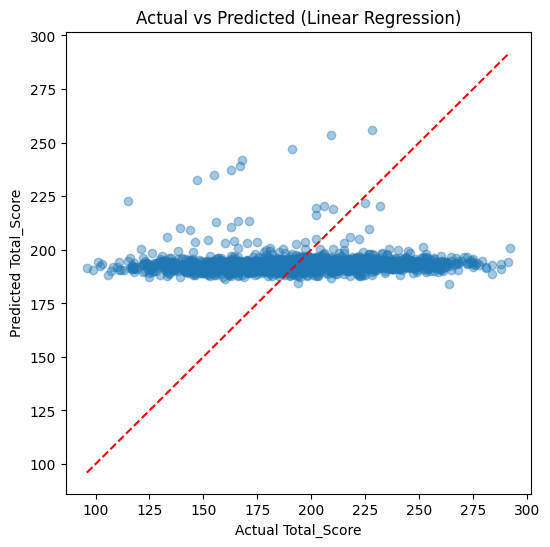

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total_Score')
plt.ylabel('Predicted Total_Score')
plt.title('Actual vs Predicted (Linear Regression)')
plt.show()

### Coefficient Interpretation


In [20]:
coef_df = pd.DataFrame({'Feature': X_lin.columns, 'Coefficient': lin_model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

                          Feature  Coefficient
                 Study_Efficiency     4.892934
              Study_Hours_per_day     1.809033
                     Gender_Other     0.714461
                              Age     0.576625
                      Gender_Male     0.477129
                          Class_9     0.422590
      Parent_Education_Illiterate     0.391185
              Internet_Access_Yes     0.387844
         Parent_Education_Primary     0.279795
                          Class_7     0.270169
Parent_Education_Higher Secondary     0.267277
                          Class_8     0.193103
                          Class_6     0.139071
                     City_Rangpur     0.118031
       Parent_Education_Secondary    -0.071619
                  City_Mymensingh    -0.079759
                  City_Chattogram    -0.147921
                       City_Dhaka    -0.205831
                    City_Rajshahi    -0.243682
          Attendance_Category_Low    -0.281036
             

## Part D — Logistic Regression
**Target:** `Result` (pass = 1, fail = 0)

In [21]:
# Binary encode the target
df_encoded['Result_binary'] = (df['Result'] == 'pass').astype(int)

# Checking class balance
print("Class distribution:")
print(df_encoded['Result_binary'].value_counts())
print("\nClass proportions:")
print(df_encoded['Result_binary'].value_counts(normalize=True))

Class distribution:
Result_binary
0    5524
1    4326
Name: count, dtype: int64

Class proportions:
Result_binary
0    0.560812
1    0.439188
Name: proportion, dtype: float64


### Class Imbalance
We check the proportion of Pass vs Fail. If the classes are imbalanced (e.g., 70-30 or worse), the model may be biased toward the majority class, achieving high accuracy by simply predicting the majority label. Metrics like precision, recall, F1 and ROC-AUC become more informative than accuracy alone in such cases. We use stratified splitting to preserve the class ratio in both train and test sets.

In [22]:
drop_for_log = ['Student_ID', 'Name', 'Result', 'Result_binary']
X_log = df_encoded.drop(columns=drop_for_log, errors='ignore')
y_log = df_encoded['Result_binary']

# Stratified split before scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

# Training Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.5583756345177665
Precision: 0.43902439024390244
Recall: 0.020809248554913295
F1 Score: 0.039735099337748346
ROC-AUC: 0.5164135694295504


### Confusion Matrix

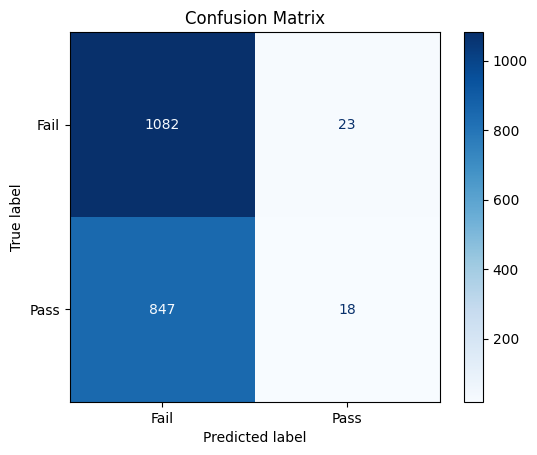

In [23]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### ROC Curve

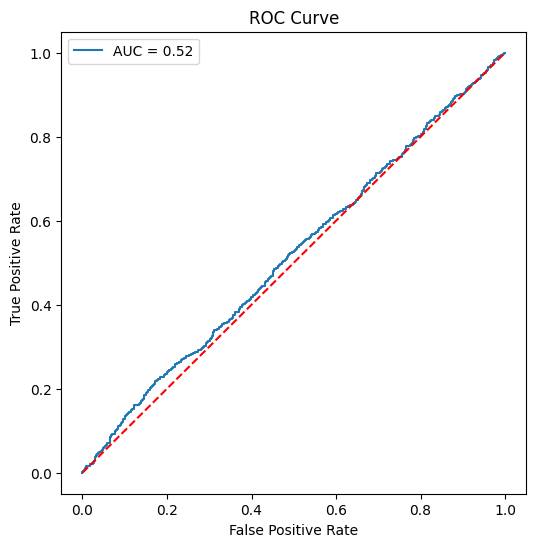

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Coefficient Interpretation
In logistic regression, each coefficient represents the change in log-odds of passing for a one-standard-deviation increase in that feature. The odds ratio exp(coefficient) gives the multiplicative change in odds.

In [25]:
log_coef_df = pd.DataFrame({
    'Feature': X_log.columns,
    'Coefficient (log-odds)': log_model.coef_[0],
    'Odds Ratio': np.exp(log_model.coef_[0])
}).sort_values('Coefficient (log-odds)', ascending=False)

print("Top features:")
print(log_coef_df.head(10).to_string(index=False))

# Interpret at least 2 coefficients
top2 = log_coef_df.head(2)
for _, row in top2.iterrows():
    feat = row['Feature']
    coef = row['Coefficient (log-odds)']
    odds = row['Odds Ratio']
    print(f"\n=> {feat}: log-odds = {coef:.4f}, odds ratio = {odds:.4f}")
    print(f"   A one-SD increase in '{feat}' multiplies the odds of passing by {odds:.2f}.")

Top features:
                          Feature  Coefficient (log-odds)  Odds Ratio
Parent_Education_Higher Secondary                0.058223    1.059951
      Parent_Education_Illiterate                0.045628    1.046685
          Attendance_Category_Low                0.042064    1.042961
                              Age                0.041296    1.042160
         Parent_Education_Primary                0.035485    1.036122
   Parent_Education_Post Graduate                0.034952    1.035570
            Attendance_Percentage                0.032538    1.033073
       Parent_Education_Secondary                0.026375    1.026726
                       Math_Score                0.015868    1.015995
                          Class_6                0.015556    1.015678

=> Parent_Education_Higher Secondary: log-odds = 0.0582, odds ratio = 1.0600
   A one-SD increase in 'Parent_Education_Higher Secondary' multiplies the odds of passing by 1.06.

=> Parent_Education_Illiterate: log-o

In [26]:
# Class balance check
df['Result'].value_counts(normalize=True)

,proportion
Result,
fail,0.560812
pass,0.439188
